## Import Libraries

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
kfold = StratifiedKFold(n_splits=5)
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import classification_report

import warnings
warnings.filterwarnings('ignore')

## Load the Dataset

In [4]:
# Load the dataset and show top 5 rows
df_raw = pd.read_csv(r"C:\Users\Bhawna\Downloads\loan_approval_dataset.csv")
df_raw.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


## Checking Outliers and null values

In [5]:
print(f'Checking data types:\n{df_raw.dtypes}\n\nChecking null values:\n{df_raw.isna().sum()}')

Checking data types:
loan_id                       int64
 no_of_dependents             int64
 education                   object
 self_employed               object
 income_annum                 int64
 loan_amount                  int64
 loan_term                    int64
 cibil_score                  int64
 residential_assets_value     int64
 commercial_assets_value      int64
 luxury_assets_value          int64
 bank_asset_value             int64
 loan_status                 object
dtype: object

Checking null values:
loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64


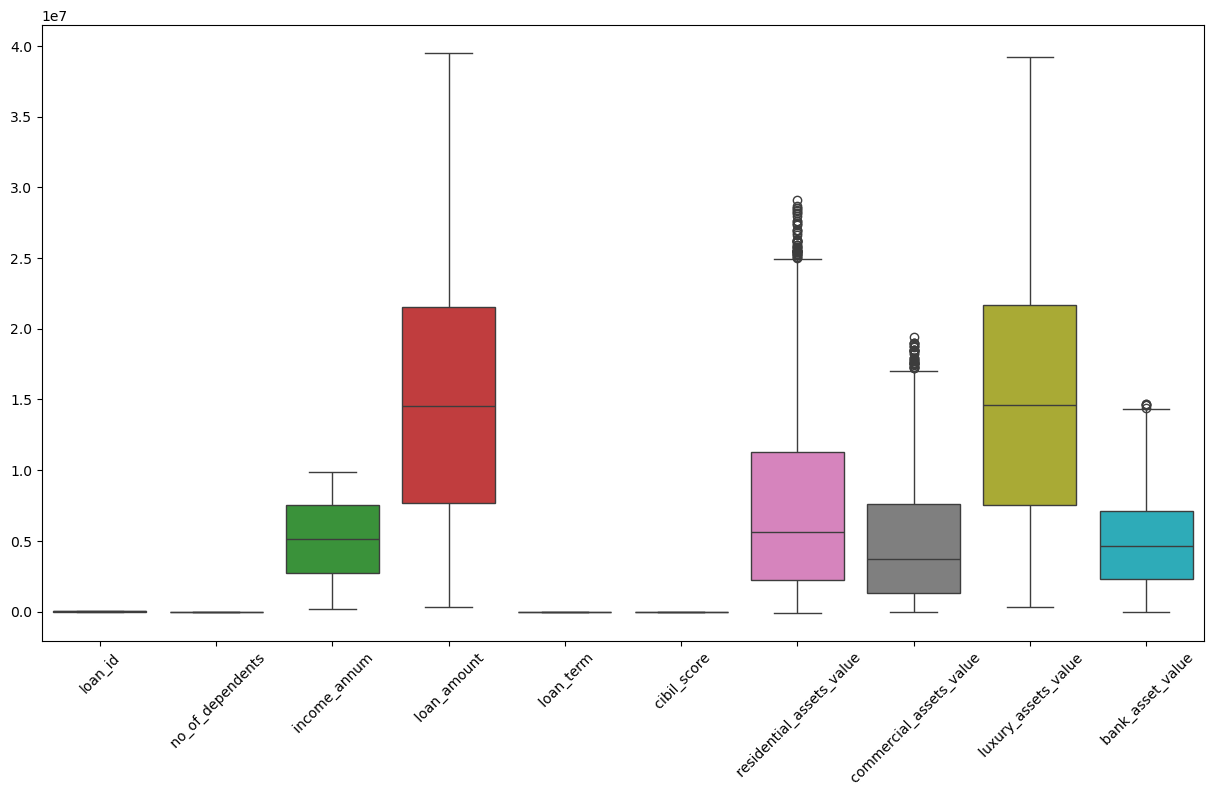

In [6]:
# Checking the outliers in data
plt.figure(figsize=(15,8))
sns.boxplot(df_raw)
plt.xticks(rotation=45)
plt.show()

In [7]:
df_raw.columns = df_raw.columns.str.strip()

In [8]:
# Treating the outliers
columns = ['residential_assets_value','commercial_assets_value','bank_asset_value']
for i in columns:
    q1 = df_raw[i].quantile(0.25)
    q3 = df_raw[i].quantile(0.75)

    # Define inter quartile range
    IQR = q3 - q1

    # Calculate lower bound and the upper bound
    lower_bound = q1 - 1.5*IQR
    upper_bound = q3 + 1.5*IQR

    # Now clip the outliers
    df_raw[i] = np.clip(df_raw[i], lower_bound, upper_bound)


## Scaling numerical features

In [9]:
# Separate numerical columns for scaling
numerical_cols = df_raw.select_dtypes(include=np.number).columns

# Call the library
sc = StandardScaler()

# Store the values after scaling in scaled_values
scaled_values = sc.fit_transform(df_raw[numerical_cols])

# Copy the original dataset and changed its numerical columns values into stored scaled_values
df_scaled = df_raw.copy()
df_scaled[numerical_cols] = scaled_values

## Change categorical columns into numerical columns

In [10]:
# Separate categorical columns for label encoding
categorical_cols = df_scaled.select_dtypes(exclude=np.number).columns

# Make a copy of df_scaled
df_final = df_scaled.copy()

# Make a loop for picking the categorical columns one by one
for col in categorical_cols:
    le = LabelEncoder()
    df_final[col] = le.fit_transform(df_final[col])


In [11]:
##  Final Dataset Prepared
df_final.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,-1.731645,-0.294102,0,0,1.617979,1.633052,0.192617,1.032792,-0.783495,2.770319,0.832028,0.930707,0
1,-1.730834,-1.473548,1,1,-0.341750,-0.324414,-0.508091,-1.061051,-0.736995,-0.633638,-0.694993,-0.515991,1
2,-1.730022,0.295621,0,0,1.439822,1.610933,1.594031,-0.544840,-0.055003,-0.106426,1.996520,2.408185,1
3,-1.729211,0.295621,0,0,1.119139,1.721525,-0.508091,-0.771045,1.665478,-0.381493,0.897943,0.899926,1
4,-1.728399,1.475067,1,1,1.689242,1.002681,1.594031,-1.264055,0.766488,0.741698,1.568075,0.007282,1


## Split the data into train test split

In [12]:
# Split the data into x and y
x = df_final.drop(['loan_status'], axis=1)
y = df_final[['loan_status']]

# Split it in now train and test data
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.7,
                                                     random_state=42, stratify=y)

In [ ]:
## Checking the shape of train and test data
print(f'Shape of X train: {x_train.shape}')
print(f'Shape of X test: {x_test.shape}')
print(f'Shape of Y train: {y_train.shape}')
print(f'Shape of Y test: {y_test.shape}')


Shape of X train: (2988, 12)
Shape of X test: (1281, 12)
Shape of Y train: (2988, 1)
Shape of Y test: (1281, 1)


## Model Training

In [ ]:
## Logistic Regression
lr = LogisticRegression()

# Make a grid of hyperparameters
grid = {'penalty': ['l1', 'l2', 'elasticnet'],
    'class_weight': ['balanced'],
    'random_state': [36,40,42],
    'solver': ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'],
    'max_iter': [50,60,80,100],
    'multi_class': ['auto', 'ovr', 'multinomial'],
    'n_jobs':[-1]}

# Build the model by fitting these parameters
grid_lr = RandomizedSearchCV(estimator=lr,
                             param_distributions=grid,
                             n_jobs=-1)

grid_lr.fit(x_train, y_train)

RandomizedSearchCV(estimator=LogisticRegression(), n_jobs=-1,
                   param_distributions={'class_weight': ['balanced'],
                                        'max_iter': [50, 60, 80, 100],
                                        'multi_class': ['auto', 'ovr',
                                                        'multinomial'],
                                        'n_jobs': [-1],
                                        'penalty': ['l1', 'l2', 'elasticnet'],
                                        'random_state': [36, 40, 42],
                                        'solver': ['lbfgs', 'liblinear',
                                                   'newton-cg',
                                                   'newton-cholesky', 'sag',
                                                   'saga']})

In [26]:
# Extracting the best estimators
best_lr = grid_lr.best_estimator_

# Fit the model
best_lr.fit(x_train, y_train)

# Make Classification report
y_pred = best_lr.predict(x_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.93      0.95       797
           1       0.89      0.94      0.92       484

    accuracy                           0.93      1281
   macro avg       0.93      0.94      0.93      1281
weighted avg       0.94      0.93      0.93      1281



In [ ]:
## Random Forest Classifier

rf = RandomForestClassifier()

# Make a grid of hyperparameters
grid_rf = {'n_estimators': [70,80,90,100],
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [4,5,6],
    'max_features': ['sqrt', 'log2'],
    'n_jobs': [-1],
    'random_state': [36,40,42],
    'class_weight': ['balanced', 'balanced_subsample']}

# Build model using the grid
rf_model = RandomizedSearchCV(estimator=rf,
                              param_distributions=grid_rf,
                              n_iter=5,
                              n_jobs=-1)

rf_model.fit(x_train, y_train)

RandomizedSearchCV(estimator=RandomForestClassifier(), n_iter=5, n_jobs=-1,
                   param_distributions={'class_weight': ['balanced',
                                                         'balanced_subsample'],
                                        'criterion': ['gini', 'entropy',
                                                      'log_loss'],
                                        'max_depth': [4, 5, 6],
                                        'max_features': ['sqrt', 'log2'],
                                        'n_estimators': [70, 80, 90, 100],
                                        'n_jobs': [-1],
                                        'random_state': [36, 40, 42]})

In [27]:
# Extract the best estimators
best_rf = rf_model.best_estimator_

# Fit the model
best_rf.fit(x_train, y_train)

# Make the classification report
y_pred_rf = best_rf.predict(x_test)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.99      0.95      0.97       797
           1       0.93      0.98      0.95       484

    accuracy                           0.96      1281
   macro avg       0.96      0.97      0.96      1281
weighted avg       0.97      0.96      0.96      1281



In [32]:
## XG Boost Classifier

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(x_train, y_train)

# Predictions
y_pred_xgb = xgb.predict(x_test)

# Classification report
print(classification_report(y_test, y_pred_xgb))


              precision    recall  f1-score   support

           0       0.99      0.99      0.99       797
           1       0.98      0.98      0.98       484

    accuracy                           0.98      1281
   macro avg       0.98      0.98      0.98      1281
weighted avg       0.98      0.98      0.98      1281



## Model Comparison

In [34]:
## For Logistic regression
acc_lr = accuracy_score(y_test, y_pred)
pre_lr = precision_score(y_test, y_pred)
rec_lr = recall_score(y_test, y_pred)
f1_lr = f1_score(y_test, y_pred)
roc_auc_lr = roc_auc_score(y_test, y_pred)

## For Random forest classifier
acc_rf = accuracy_score(y_test, y_pred_rf)
pre_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_pred_rf)

## For XG Boost Classifier
acc_xgb = accuracy_score(y_test, y_pred_xgb)
pre_xgb = precision_score(y_test, y_pred_xgb)
rec_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_pred_xgb)

In [ ]:
# Create key value pair of results
results = {'models': ['LogisticRegression', 'RandomForestClassifier', 'XGBClassifier'],
           'Accuracy': [acc_lr, acc_rf, acc_xgb],
           'Precision': [pre_lr, pre_rf, pre_xgb],
           'Recall': [rec_lr, rec_rf, rec_xgb],
           'F1 Score': [f1_lr, f1_rf, f1_xgb],
           'Roc-Auc Score': [roc_auc_lr, roc_auc_rf, roc_auc_xgb]}

In [37]:
# Make result's dataframe
comparison_df = pd.DataFrame(results)
comparison_df

,models,Accuracy,Precision,Recall,F1 Score,Roc-Auc Score
0,LogisticRegression,0.934426,0.893701,0.938017,0.915323,0.935131
1,RandomForestClassifier,0.964091,0.929412,0.979339,0.953722,0.967085
2,XGBClassifier,0.984387,0.983333,0.975207,0.979253,0.982584


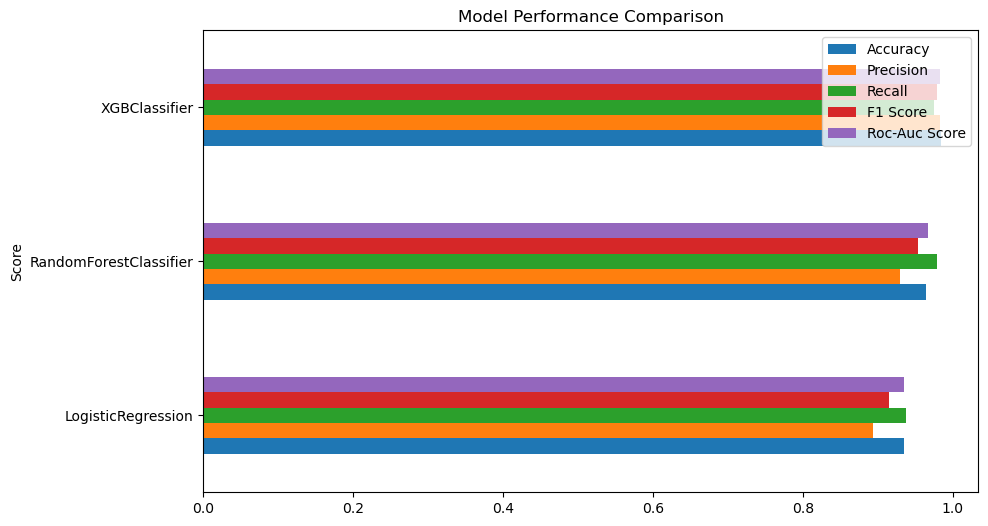

In [ ]:
# Horizontal Bar graph for the comparison of model's performance
comparison_df.set_index('models').plot(kind='barh', figsize=(10,6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.show()

## Feature Importance

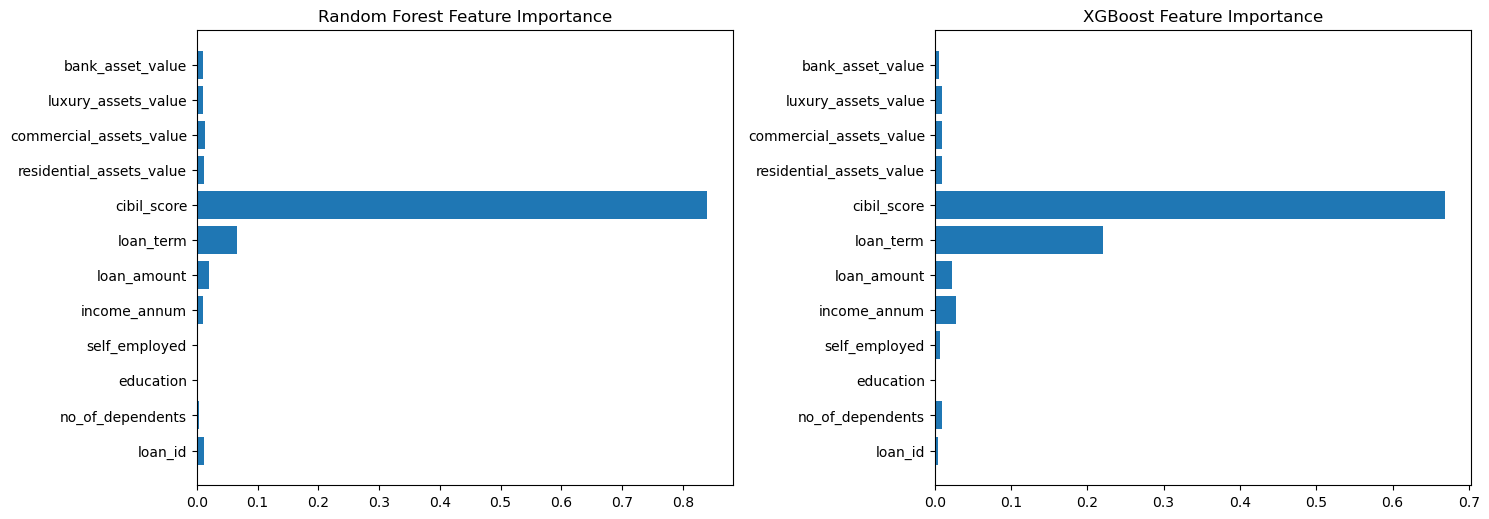

In [45]:
# Random Forest
plt.figure(figsize=(15,10))
plt.subplot(2,2,1)
importances_rf = best_rf.feature_importances_
plt.barh(x_train.columns, importances_rf)
plt.title("Random Forest Feature Importance")

# XGBoost
plt.subplot(2,2,2)
importances_xgb = xgb.feature_importances_
plt.barh(x_train.columns, importances_xgb)
plt.title("XGBoost Feature Importance")

plt.tight_layout()
plt.show()